Rows: 254 Columns: 404
-- Column specification --------------------------------------------------------
Delimiter: ","
chr   (1): County
dbl (380): cve, outbreak, enrollment, PHR, pct_hispanic, pct_black, pct_whit...
lgl  (23): median_income, Advised to Cut Down Salt - Do not use salt, Diabet...

i Use `spec()` to retrieve the full column specification for this data.
i Specify the column types or set `show_col_types = FALSE` to quiet this message.
Warning message in cor(rank(x), rank(y)):
"Standardabweichung ist Null"
Warning message in cor(rank(x), rank(y)):
"Standardabweichung ist Null"
Warning message in cor(rank(x), rank(y)):
"Standardabweichung ist Null"
Warning message in cor(rank(x), rank(y)):
"Standardabweichung ist Null"
Warning message in cor(rank(x), rank(y)):
"Standardabweichung ist Null"
Warning message in cor(rank(x), rank(y)):
"Standardabweichung ist Null"
Warning message in cor(rank(x), rank(y)):
"Standardabweichung ist Null"
Warning message in cor(rank(x), rank(y)):
"S

After Spearman screen: 220 candidates
# A tibble: 220 x 3
   variable                                                   rho     p_value
   <chr>                                                    <dbl>       <dbl>
 1 Mammogram Past 2 Yrs 40+ IA - No                         0.311 0.000000415
 2 Mammogram Past 2 Yrs 40+ IA - Yes                       -0.311 0.000000415
 3 Mammogram Past 2 Yrs 50+ IA - Yes                       -0.309 0.000000527
 4 Mammogram Past 2 Yrs 50+ IA - No                         0.309 0.000000527
 5 Poor Mental Health 14+ Days - None to less than 14 days  0.306 0.000000664
 6 Poor Mental Health 14+ Days - 14 or more days           -0.306 0.000000664
 7 Sigm Past 5 Yrs Age 50-75 - No                           0.301 0.00000101 
 8 Sigm Past 5 Yrs 50-75 IA - No                            0.301 0.00000101 
 9 Depressive Disorder - No                                 0.292 0.00000222 
10 Depressive Disorder - Yes                               -0.292 0.00000222 
# i 21

 Family: nbinom2  ( log )
Formula:          
outbreak ~ cve + `Smokeless Tobacco Use - Every day` + `Current E-cig User - Yes` +  
    `ClnscpySgmscpy - Both` + `RxPainRiskEd Source - Yes` + `COPD - Yes` +  
    `Cervical Cancer Screening Pa - No` + pct_uninsured + `Stool DNA Past 3 Yrs Age 50- - Yes` +  
    pct_white + offset(log(enrollment)) + (1 | PHR)
Data: model_df

      AIC       BIC    logLik -2*log(L)  df.resid 
    372.6     418.4    -173.3     346.6       236 

Random effects:

Conditional model:
 Groups Name        Variance  Std.Dev. 
 PHR    (Intercept) 6.181e-09 7.862e-05
Number of obs: 249, groups:  PHR, 11

Dispersion parameter for nbinom2 family (): 0.161 

Conditional model:
                                       Estimate Std. Error z value Pr(>|z|)   
(Intercept)                          -13.075928   9.893765  -1.322  0.18629   
cve                                    0.360392   0.184301   1.955  0.05053 . 
`Smokeless Tobacco Use - Every day`    0.683259   0.722802  

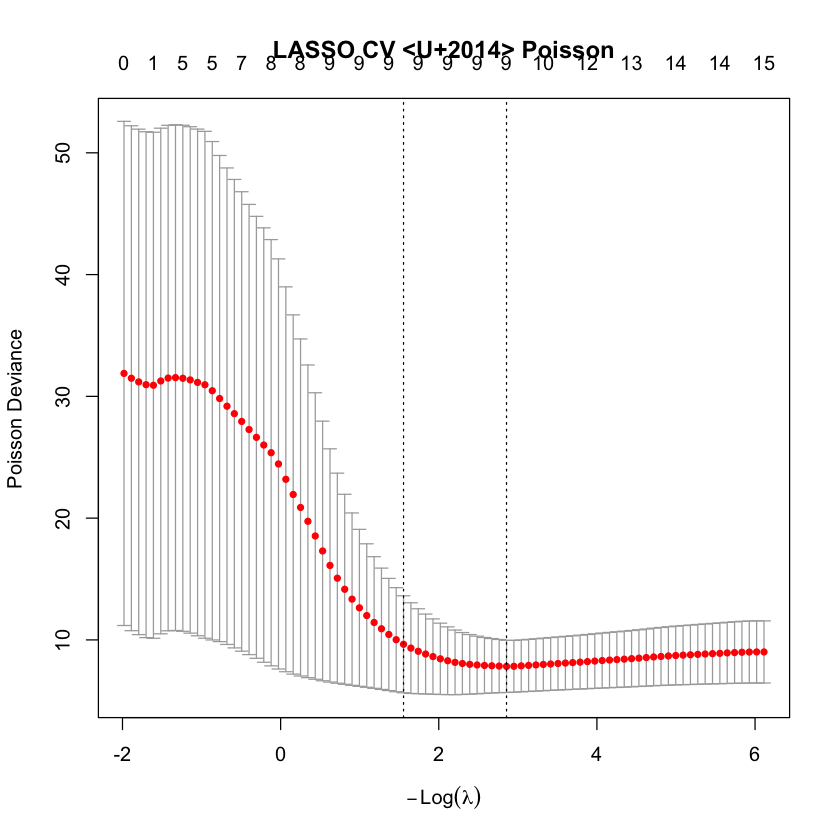

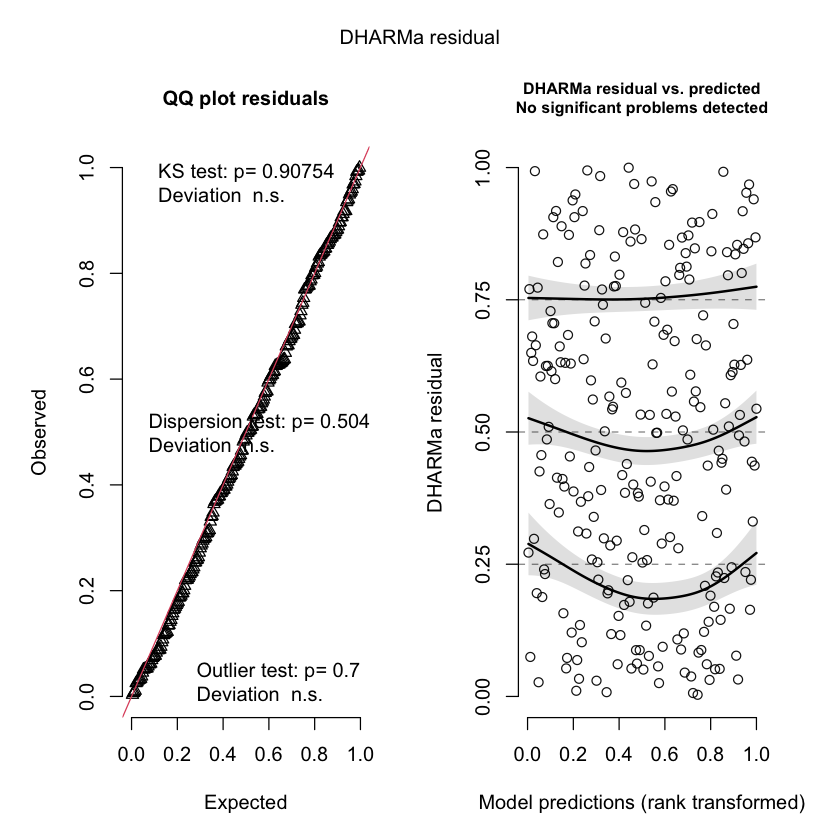

In [5]:
library(tidyverse)
library(glmnet)
library(glmmTMB)
library(caret)
library(DHARMa)

df <- read_csv("data/merged_data.csv")

outcome    <- df$outbreak
offset_var <- log(df$enrollment)
PHR        <- df$PHR
 
X_all <- df %>%
  select(-County, -cve, -outbreak, -enrollment, -PHR) %>%
  mutate(across(everything(), ~ suppressWarnings(as.numeric(as.character(.))))) %>%
  mutate(across(everything(), ~ ifelse(is.na(.), median(., na.rm = TRUE), .)))

# keep p < 0.2
 
spearman_screen <- function(X, y, p_threshold = 0.2) {
  map_dfr(names(X), function(var) {
    x  <- X[[var]]
    ok <- !is.na(x) & !is.na(y)
    if (sum(ok) < 10) return(NULL)
    test <- cor.test(x[ok], y[ok], method = "spearman", exact = FALSE)
    tibble(variable = var, rho = test$estimate, p_value = test$p.value)
  }) %>%
    filter(p_value < p_threshold) %>%
    arrange(p_value)
}
 
candidates <- spearman_screen(X_all, outcome)
cat("After Spearman screen:", nrow(candidates), "candidates\n")
print(candidates)
 
 
# drop variables |r| > 0.70
 
X_cand    <- X_all[, candidates$variable, drop = FALSE]
cor_mat   <- cor(X_cand, use = "pairwise.complete.obs")
to_remove <- findCorrelation(cor_mat, cutoff = 0.70, names = TRUE)
X_filt    <- X_cand[, !names(X_cand) %in% to_remove, drop = FALSE]
cat("After collinearity filter:", ncol(X_filt), "variables\n")
 
 
# Drop rows with NA 
 
valid      <- !is.na(outcome) & is.finite(offset_var)
y          <- outcome[valid]
offs       <- offset_var[valid]
phr        <- factor(PHR[valid])
X_clean    <- X_filt[valid, , drop = FALSE]
 
 
# LASSO  (Poisson, lambda.1se) 
 
X_mat <- model.matrix(~ . - 1, data = X_clean)
 
set.seed(42)
cv_lasso <- cv.glmnet(
  x      = X_mat,
  y      = y,
  offset = offs,
  family = "poisson",
  alpha  = 1            # LASSO
)
plot(cv_lasso, main = "LASSO CV — Poisson")
 
lasso_coef <- coef(cv_lasso, s = "lambda.1se")
lasso_vars <- rownames(lasso_coef)[
  lasso_coef[, 1] != 0 & !grepl("Intercept", rownames(lasso_coef))
]
# model.matrix may wrap names with spaces in backticks — strip them
lasso_vars <- gsub("^`|`$", "", lasso_vars)
# keep only names that exist in X_clean
lasso_vars <- lasso_vars[lasso_vars %in% names(X_clean)]
 
cat("\nLASSO selected", length(lasso_vars), "variables:\n")
print(lasso_vars)
cat("cve in LASSO-selected vars:", "cve" %in% lasso_vars, "\n")
 
 
# outbreak ~ cve + lasso_vars + offset + (1|PHR)
 
keep_vars <- union("cve", lasso_vars)     
 
model_df <- bind_cols(
  outbreak   = y,
  enrollment = exp(offs),
  PHR        = phr,
  df[valid, "cve", drop = FALSE],          # pull cve from original df
  X_clean[, setdiff(keep_vars, "cve"), drop = FALSE]
)
 
formula_final <- reformulate(
  termlabels = c(
    paste0("`", keep_vars, "`"),
    "offset(log(enrollment))",
    "(1 | PHR)"
  ),
  response = "outbreak"
)
 
fit_final <- glmmTMB(formula_final, data = model_df, family = nbinom2())
summary(fit_final)
 
 
# ── 7. DHARMa diagnostics ────────────────────────────────────────────────────
 
sim <- simulateResiduals(fit_final)
plot(sim)

After 12 iterations, +1.2 secs: 

 rejected 13 attributes: Cervical Cancer Screening Pa - No, Difficulty Concentrating - Yes, General Health - Good, Heavy Drinking - Females - Yes, Interfere w Social Act - Usually and 8 more;

 still have 14 attributes left.


After 16 iterations, +1.5 secs: 

 rejected 8 attributes: BMI 5 Categories - Underweight, ClnscpySgmscpy - Both, Current E-cig User - Yes, Kidney Disease - Yes, Quit Smoking in Past Yr - No and 3 more;

 still have 6 attributes left.


After 19 iterations, +1.7 secs: 

 rejected 3 attributes: Hlth Affected Activ 5+ Days - None to less than 5 days, Pap Test Past 3 Yrs 21-65 IA - No, Sigm Past 10 Yrs 50-75 IA - No;

 still have 3 attributes left.


After 38 iterations, +2.8 secs: 

 rejected 1 attribute: Poor Mental Health 5+ Days - 5 or more days;

 still have 2 attributes left.




Boruta confirmed 1 variables:
[1] "pct_uninsured"


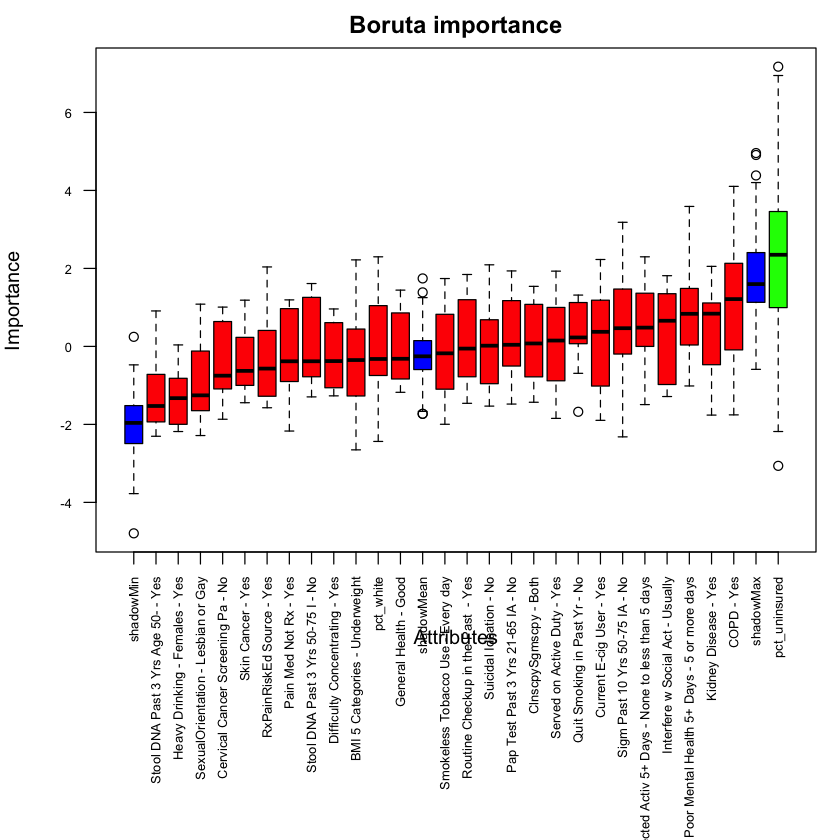

In [6]:
library(Boruta)

set.seed(42)
boruta_out <- Boruta(x = X_clean, y = y, maxRuns = 150, doTrace = 1)

boruta_fixed <- TentativeRoughFix(boruta_out)
boruta_vars  <- getSelectedAttributes(boruta_fixed, withTentative = FALSE)

cat("Boruta confirmed", length(boruta_vars), "variables:\n")
print(boruta_vars)

# Plot
par(mar = c(12, 4, 2, 1))
plot(boruta_fixed, las = 2, cex.axis = 0.65, main = "Boruta importance")

Rows: 254 Columns: 555
-- Column specification --------------------------------------------------------
Delimiter: ","
chr   (1): County
dbl (531): cve, outbreak, enrollment, PHR, pct_hispanic, pct_black, pct_whit...
lgl  (23): median_income, Advised to Cut Down Salt - Do not use salt, Diabet...

i Use `spec()` to retrieve the full column specification for this data.
i Specify the column types or set `show_col_types = FALSE` to quiet this message.


Covariate matrix: 254 rows x 550 columns


Warning message in cor(rank(x), rank(y)):
"Standardabweichung ist Null"
Warning message in cor(rank(x), rank(y)):
"Standardabweichung ist Null"
Warning message in cor(rank(x), rank(y)):
"Standardabweichung ist Null"
Warning message in cor(rank(x), rank(y)):
"Standardabweichung ist Null"
Warning message in cor(rank(x), rank(y)):
"Standardabweichung ist Null"
Warning message in cor(rank(x), rank(y)):
"Standardabweichung ist Null"
Warning message in cor(rank(x), rank(y)):
"Standardabweichung ist Null"
Warning message in cor(rank(x), rank(y)):
"Standardabweichung ist Null"
Warning message in cor(rank(x), rank(y)):
"Standardabweichung ist Null"
Warning message in cor(rank(x), rank(y)):
"Standardabweichung ist Null"
Warning message in cor(rank(x), rank(y)):
"Standardabweichung ist Null"
Warning message in cor(rank(x), rank(y)):
"Standardabweichung ist Null"
Warning message in cor(rank(x), rank(y)):
"Standardabweichung ist Null"
Warning message in cor(rank(x), rank(y)):
"Standardabweichung is

After Spearman screen: 276 candidates
# A tibble: 276 x 3
   variable                                                   rho     p_value
   <chr>                                                    <dbl>       <dbl>
 1 Mammogram Past 2 Yrs 40+ IA - No                         0.311 0.000000415
 2 Mammogram Past 2 Yrs 40+ IA - Yes                       -0.311 0.000000415
 3 Mammogram Past 2 Yrs 50+ IA - Yes                       -0.309 0.000000527
 4 Mammogram Past 2 Yrs 50+ IA - No                         0.309 0.000000527
 5 Poor Mental Health 14+ Days - None to less than 14 days  0.306 0.000000664
 6 Poor Mental Health 14+ Days - 14 or more days           -0.306 0.000000664
 7 Sigm Past 5 Yrs Age 50-75 - No                           0.301 0.00000101 
 8 Sigm Past 5 Yrs 50-75 IA - No                            0.301 0.00000101 
 9 Depressive Disorder - No                                 0.292 0.00000222 
10 Depressive Disorder - Yes                               -0.292 0.00000222 
# i 26

 Family: nbinom2  ( log )
Formula:          
outbreak ~ cve + `Kidney Disease - Yes` + `ClnscpySgmscpy - Both` +  
    `Suicidal Ideation - Yes` + F_LIMENG + E_LIMENG + `Quit Smoking in Past Yr - No` +  
    `Cervical Cancer Screening Pa - No` + pct_uninsured + offset(log(enrollment)) +  
    (1 | PHR)
Data: model_df

      AIC       BIC    logLik -2*log(L)  df.resid 
    379.9     422.1    -178.0     355.9       237 

Random effects:

Conditional model:
 Groups Name        Variance Std.Dev.
 PHR    (Intercept) 1.624    1.274   
Number of obs: 249, groups:  PHR, 11

Dispersion parameter for nbinom2 family (): 0.162 

Conditional model:
                                      Estimate Std. Error z value Pr(>|z|)   
(Intercept)                          7.832e+00  1.310e+01   0.598  0.54998   
cve                                  3.217e-01  1.761e-01   1.827  0.06772 . 
`Kidney Disease - Yes`              -5.643e-02  1.025e+00  -0.055  0.95610   
`ClnscpySgmscpy - Both`             -4.576e-

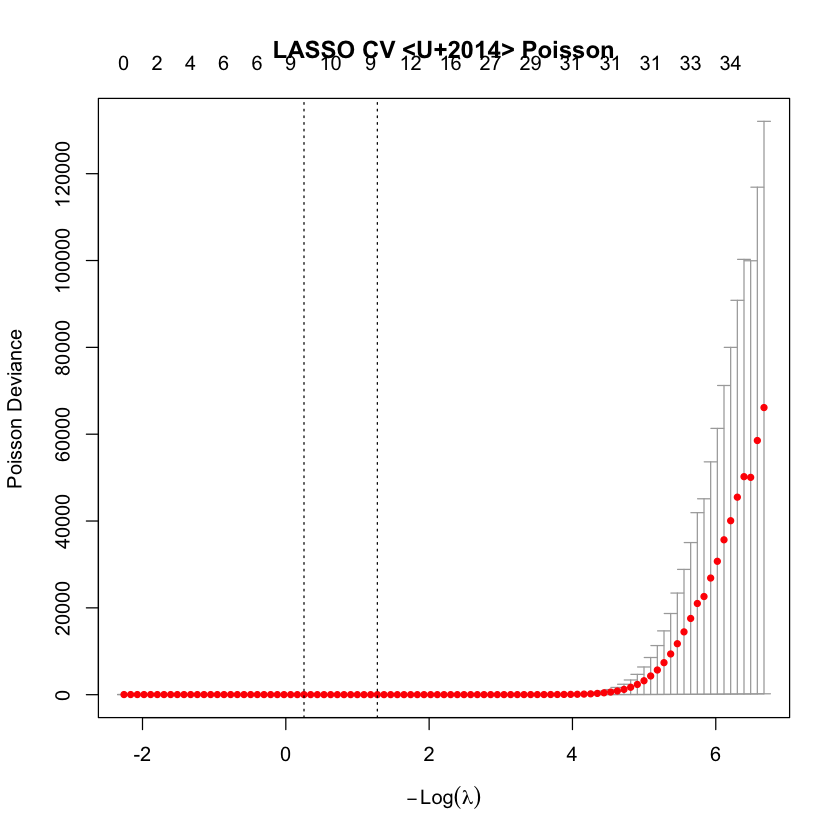

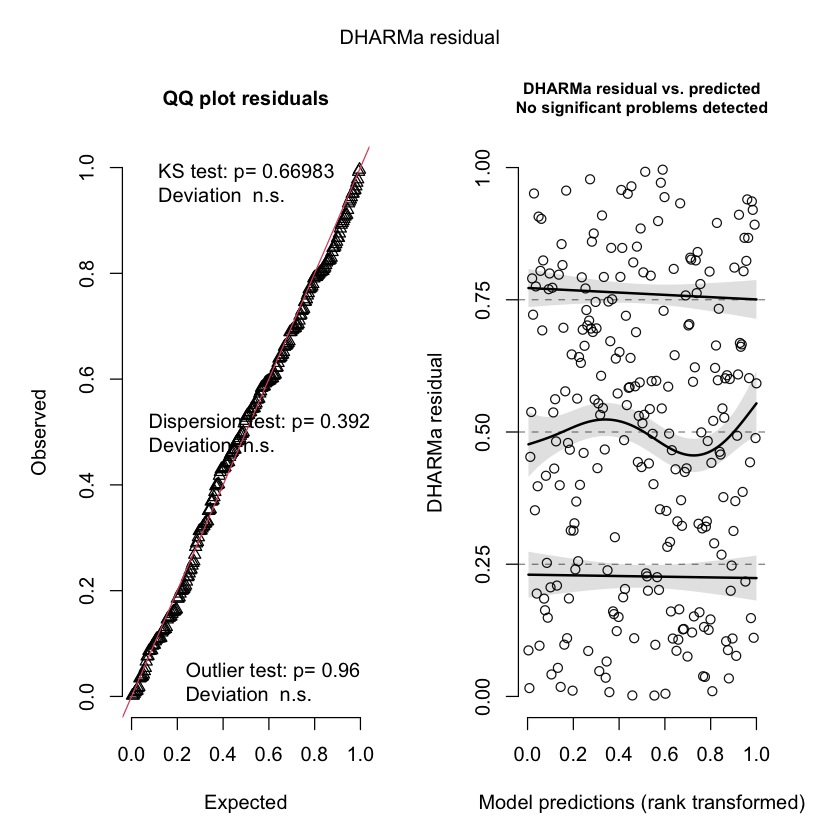

In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# outbreak ~ automated variable selection pipeline
# Data     : merged_with_svi.csv  (254 counties, 555 columns)
# Outcome  : outbreak (count)
# Offset   : log(enrollment)
# Random FX: (1 | PHR)
# Family   : nbinom2
# ══════════════════════════════════════════════════════════════════════════════

library(tidyverse)
library(glmnet)
library(glmmTMB)
library(caret)
library(DHARMa)


# ── 0. Load data ──────────────────────────────────────────────────────────────

df <- read_csv("data/merged_with_svi.csv")


# ── 1. Define outcome, offset, grouping, and covariate matrix ─────────────────

outcome    <- df$outbreak
offset_var <- log(df$enrollment)
PHR        <- df$PHR

# All columns except identifiers and outcomes
X_all <- df %>%
  select(-County, -cve, -outbreak, -enrollment, -PHR) %>%
  mutate(across(everything(), ~ suppressWarnings(as.numeric(as.character(.))))) %>%
  mutate(across(everything(), ~ ifelse(is.na(.), median(., na.rm = TRUE), .)))

cat("Covariate matrix:", nrow(X_all), "rows x", ncol(X_all), "columns\n")


# ── 2. Spearman screen  (keep p < 0.2) ───────────────────────────────────────

spearman_screen <- function(X, y, p_threshold = 0.2) {
  map_dfr(names(X), function(var) {
    x  <- X[[var]]
    ok <- !is.na(x) & !is.na(y)
    if (sum(ok) < 10) return(NULL)
    test <- cor.test(x[ok], y[ok], method = "spearman", exact = FALSE)
    tibble(variable = var, rho = test$estimate, p_value = test$p.value)
  }) %>%
    filter(p_value < p_threshold) %>%
    arrange(p_value)
}

candidates <- spearman_screen(X_all, outcome)
cat("After Spearman screen:", nrow(candidates), "candidates\n")
print(candidates)


# ── 3. Collinearity filter  (drop variables with |r| > 0.70) ─────────────────

X_cand    <- X_all[, candidates$variable, drop = FALSE]
cor_mat   <- cor(X_cand, use = "pairwise.complete.obs")
to_remove <- findCorrelation(cor_mat, cutoff = 0.70, names = TRUE)
X_filt    <- X_cand[, !names(X_cand) %in% to_remove, drop = FALSE]
cat("After collinearity filter:", ncol(X_filt), "variables\n")


# ── 4. Drop rows with NA outcome or non-finite offset ────────────────────────

valid   <- !is.na(outcome) & is.finite(offset_var)
y       <- outcome[valid]
offs    <- offset_var[valid]
phr     <- factor(PHR[valid])
X_clean <- X_filt[valid, , drop = FALSE]

cat("Rows after cleaning:", sum(valid), "\n")


# ── 5. LASSO  (Poisson, lambda.1se) ──────────────────────────────────────────

X_mat <- model.matrix(~ . - 1, data = X_clean)

set.seed(42)
cv_lasso <- cv.glmnet(
  x      = X_mat,
  y      = y,
  offset = offs,
  family = "poisson",
  alpha  = 1
)
plot(cv_lasso, main = "LASSO CV — Poisson")

lasso_coef <- coef(cv_lasso, s = "lambda.1se")
lasso_vars <- rownames(lasso_coef)[
  lasso_coef[, 1] != 0 & !grepl("Intercept", rownames(lasso_coef))
]
lasso_vars <- gsub("^`|`$", "", lasso_vars)
lasso_vars <- lasso_vars[lasso_vars %in% names(X_clean)]

cat("\nLASSO selected", length(lasso_vars), "variables:\n")
print(lasso_vars)

cat("cve selected by LASSO:", "cve" %in% lasso_vars, "\n")


# ── 6. Final model  outbreak ~ cve + lasso_vars + offset + (1|PHR) ───────────

keep_vars <- union("cve", lasso_vars)

model_df <- bind_cols(
  outbreak   = y,
  enrollment = exp(offs),
  PHR        = phr,
  df[valid, "cve", drop = FALSE],
  X_clean[, setdiff(keep_vars, "cve"), drop = FALSE]
)

formula_final <- reformulate(
  termlabels = c(
    paste0("`", keep_vars, "`"),
    "offset(log(enrollment))",
    "(1 | PHR)"
  ),
  response = "outbreak"
)

fit_final <- glmmTMB(formula_final, data = model_df, family = nbinom2())
summary(fit_final)


# ── 7. DHARMa diagnostics ────────────────────────────────────────────────────

sim <- simulateResiduals(fit_final)
plot(sim)

After 13 iterations, +1.6 secs: 

 rejected 39 attributes: A One C - Yes, BMI 5 Categories - Underweight, COPD - Yes, Cervical Cancer Screening Pa - No, ClnscpySgmscpy - Both and 34 more;

 still have 9 attributes left.


After 17 iterations, +2 secs: 

 rejected 1 attribute: F_NOHSDP;

 still have 8 attributes left.


After 20 iterations, +2.2 secs: 

 rejected 1 attribute: E_NHPI;

 still have 7 attributes left.


After 44 iterations, +3.9 secs: 

 rejected 1 attribute: E_LIMENG;

 still have 6 attributes left.


After 47 iterations, +4.1 secs: 

 rejected 1 attribute: pct_uninsured;

 still have 5 attributes left.


After 52 iterations, +4.4 secs: 

 confirmed 1 attribute: Suicidal Ideation - No;

 still have 4 attributes left.


After 60 iterations, +4.9 secs: 

 confirmed 1 attribute: RPL_THEME1;

 still have 3 attributes left.


After 66 iterations, +5.3 secs: 

 confirmed 1 attribute: EPL_MOBILE;

 still have 2 attributes left.


After 71 iterations, +5.6 secs: 

 confirmed 1 at

Boruta confirmed 5 variables:
[1] "Suicidal Ideation - No"                     
[2] "EPL_MOBILE"                                 
[3] "F_THEME1"                                   
[4] "Poor Mental Health 5+ Days - 5 or more days"
[5] "RPL_THEME1"                                 


 Family: nbinom2  ( log )
Formula:          
outbreak ~ cve + `Suicidal Ideation - No` + EPL_MOBILE + F_THEME1 +  
    `Poor Mental Health 5+ Days - 5 or more days` + RPL_THEME1 +  
    offset(log(enrollment)) + (1 | PHR)
Data: model_boruta

      AIC       BIC    logLik -2*log(L)  df.resid 
    382.4     414.1    -182.2     364.4       240 

Random effects:

Conditional model:
 Groups Name        Variance Std.Dev.
 PHR    (Intercept) 6.08     2.466   
Number of obs: 249, groups:  PHR, 11

Dispersion parameter for nbinom2 family (): 0.167 

Conditional model:
                                              Estimate Std. Error z value
(Intercept)                                   65.56229   89.24860   0.735
cve                                            0.41511    0.14088   2.946
`Suicidal Ideation - No`                      -0.68609    0.92707  -0.740
EPL_MOBILE                                    -0.28387    1.10708  -0.256
F_THEME1                                      -0.06615    0.3621

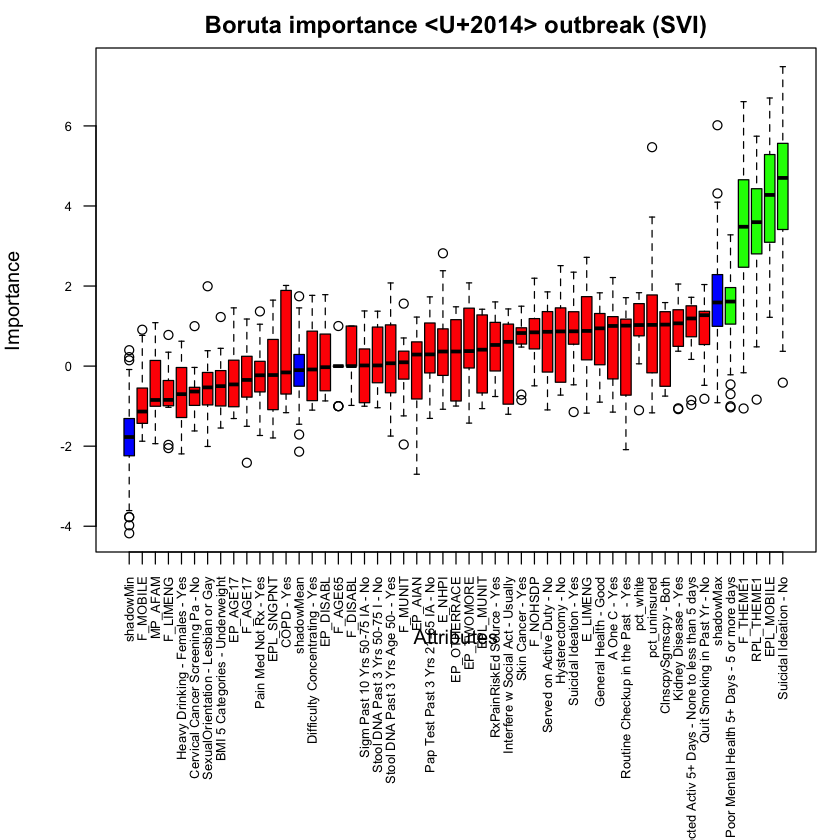


In Boruta, not LASSO: Suicidal Ideation - No EPL_MOBILE F_THEME1 Poor Mental Health 5+ Days - 5 or more days RPL_THEME1 
In LASSO, not Boruta: Kidney Disease - Yes ClnscpySgmscpy - Both Suicidal Ideation - Yes F_LIMENG E_LIMENG Quit Smoking in Past Yr - No Cervical Cancer Screening Pa - No pct_uninsured 
In both:               


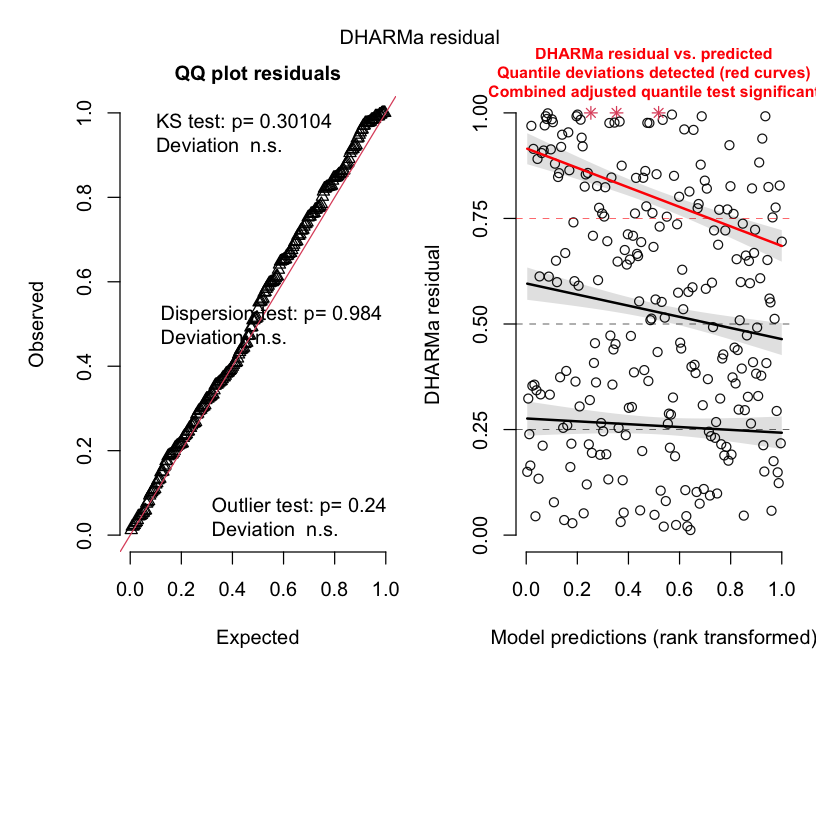

In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# Boruta variable selection
# Run after outbreak_selection_svi.R (needs X_clean, y, offs, phr, valid)
# ══════════════════════════════════════════════════════════════════════════════

library(Boruta)
library(glmmTMB)
library(DHARMa)


# ── 1. Run Boruta ─────────────────────────────────────────────────────────────

set.seed(42)
boruta_out <- Boruta(x = X_clean, y = y, maxRuns = 150, doTrace = 1)

boruta_fixed <- TentativeRoughFix(boruta_out)
boruta_vars  <- getSelectedAttributes(boruta_fixed, withTentative = FALSE)

cat("Boruta confirmed", length(boruta_vars), "variables:\n")
print(boruta_vars)

par(mar = c(12, 4, 2, 1))
plot(boruta_fixed, las = 2, cex.axis = 0.65, main = "Boruta importance — outbreak (SVI)")


# ── 2. Final model using Boruta-selected variables ───────────────────────────

keep_boruta <- union("cve", boruta_vars)

model_boruta <- bind_cols(
  outbreak   = y,
  enrollment = exp(offs),
  PHR        = phr,
  df[valid, "cve", drop = FALSE],
  X_clean[, setdiff(keep_boruta, "cve"), drop = FALSE]
)

formula_boruta <- reformulate(
  termlabels = c(
    paste0("`", keep_boruta, "`"),
    "offset(log(enrollment))",
    "(1 | PHR)"
  ),
  response = "outbreak"
)

fit_boruta <- glmmTMB(formula_boruta, data = model_boruta, family = nbinom2())
summary(fit_boruta)


# ── 3. DHARMa diagnostics ────────────────────────────────────────────────────

sim_boruta <- simulateResiduals(fit_boruta)
plot(sim_boruta)


# ── 4. Overlap with LASSO ────────────────────────────────────────────────────

cat("\nIn Boruta, not LASSO:", setdiff(boruta_vars, lasso_vars), "\n")
cat("In LASSO, not Boruta:", setdiff(lasso_vars,  boruta_vars), "\n")
cat("In both:             ", intersect(lasso_vars, boruta_vars), "\n")